In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
week10_data = pd.read_csv("sales_integrated.csv")

print("Dataset shape:", week10_data.shape)
week10_data.head()

Dataset shape: (130402, 55)


,so_id,line_number,product_id,quantity,unit_price,gst_rate,line_total,gst_amount,line_grand_total,customer_id,branch_id,order_date,delivery_date,order_status,payment_terms,total_order_value,total_gst_amount,grand_total,sales_channel,product_name,category,machine_type,brand,model_compatibility,unit_cost,unit_price_product,margin_percentage,gst_rate_product,weight_kg,dimensions_cm,material_type,warranty_months,reorder_level,safety_stock,max_stock_level,lead_time_days,criticality_level,usage_frequency,uom,last_purchase_price,last_purchase_date,customer_type,industry_segment,city,state,pincode,region,branch_id_customer,credit_limit,current_balance,payment_terms_customer,customer_since,last_purchase_date_customer,total_purchase_value,customer_rating
0,SO-990591,1,P018,19,11300,28,214700,60116.0,274816.0,C0070,AHM001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,Wheel Rim WR-24,Undercarriage,Bulldozer,CAT,CAT D6R,8200,11300,37.8,28,24.00,70x25x25,steel,12,12,6,30,20,High,Medium,piece,8000,2024-02-20,Government,Logistics,Ahmedabad,Gujarat,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
1,SO-990591,2,P026,2,310,18,620,111.6,731.6,C0070,AHM001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,Grease Cartridge GC-5,Lubricants,All,Generic,All Models,180,310,72.2,18,0.45,25x6x6,synthetic,3,200,100,500,4,Low,High,cartridge,170,2020-04-02,Government,Logistics,Ahmedabad,Gujarat,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
2,SO-990591,3,P026,3,310,18,930,167.4,1097.4,C0070,AHM001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,Grease Cartridge GC-5,Lubricants,All,Generic,All Models,180,310,72.2,18,0.45,25x6x6,synthetic,3,200,100,500,4,Low,High,cartridge,170,2020-04-02,Government,Logistics,Ahmedabad,Gujarat,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
3,SO-990591,4,P013,9,1450,18,13050,2349.0,15399.0,C0070,AHM001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,Seal Kit SK-15,Seals,Excavator,CAT,CAT 320D,950,1450,52.6,18,0.60,15x10x6,rubber,6,80,40,200,9,Medium,High,set,920,2022-12-19,Government,Logistics,Ahmedabad,Gujarat,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
4,SO-990591,5,P004,3,39800,28,119400,33432.0,152832.0,C0070,AHM001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,Track Chain TC-45,Undercarriage,Bulldozer,Volvo,Volvo D6,32500,39800,22.5,28,210.00,180x40x35,steel,18,8,4,20,30,High,Low,set,32000,2020-06-18,Government,Logistics,Ahmedabad,Gujarat,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3


In [5]:
required_columns = [
    "customer_id",
    "so_id",
    "product_id",
    "product_name",
    "quantity",
    "line_total",
    "order_date",
    "customer_type",
    "industry_segment",
    "region",
    "sales_channel"
]

missing_columns = [
    col for col in required_columns
    if col not in week10_data.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are available.")

week10_data.info()

All required columns are available.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130402 entries, 0 to 130401
Data columns (total 55 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   so_id                        130402 non-null  object 
 1   line_number                  130402 non-null  int64  
 2   product_id                   130402 non-null  object 
 3   quantity                     130402 non-null  int64  
 4   unit_price                   130402 non-null  int64  
 5   gst_rate                     130402 non-null  int64  
 6   line_total                   130402 non-null  int64  
 7   gst_amount                   130402 non-null  float64
 8   line_grand_total             130402 non-null  float64
 9   customer_id                  130402 non-null  object 
 10  branch_id                    130402 non-null  object 
 11  order_date                   130402 non-null  object 
 12  delivery_date         

### **Convert Numeric Columns**

In [6]:
numeric_columns = [
    "quantity",
    "line_total",
    "unit_price",
    "unit_cost",
    "margin_percentage",
    "customer_rating"
]

for col in numeric_columns:
    if col in week10_data.columns:
        week10_data[col] = pd.to_numeric(
            week10_data[col],
            errors="coerce"
        )

### **Convert Date Columns**

In [7]:
date_columns = [
    "order_date",
    "delivery_date",
    "customer_since",
    "last_purchase_date_customer"
]

for col in date_columns:
    if col in week10_data.columns:
        week10_data[col] = pd.to_datetime(
            week10_data[col],
            errors="coerce"
        )

### **Missing Values**

In [8]:
missing_values = (
    week10_data.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

,0


### **Duplicates Check**

In [9]:
duplicate_count = week10_data.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


### **Basic Dataset Summary**

In [10]:
print("Rows:", len(week10_data))
print("Customers:", week10_data["customer_id"].nunique())
print("Orders:", week10_data["so_id"].nunique())
print("Products:", week10_data["product_id"].nunique())

print(
    "Total Revenue: £",
    round(week10_data["line_total"].sum(), 2)
)

print(
    "Total Units Sold:",
    week10_data["quantity"].sum()
)

Rows: 130402
Customers: 500
Orders: 20000
Products: 30
Total Revenue: £ 25447392560
Total Units Sold: 1368534


## **Customer Performance Analysis**

### **Customer Performance**

In [11]:
customer_performance = (
    week10_data
    .groupby("customer_id")
    .agg(
        total_revenue=("line_total", "sum"),
        total_units=("quantity", "sum"),
        total_orders=("so_id", "nunique"),
        products_purchased=("product_id", "nunique"),
        branches_used=("branch_id", "nunique"),
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max")
    )
    .reset_index()
)

customer_performance.head()

,customer_id,total_revenue,total_units,total_orders,products_purchased,branches_used,first_order_date,last_order_date
0,C0001,52640600,2656,40,30,1,2019-01-26,2024-12-25
1,C0002,61160690,3636,56,30,1,2019-01-24,2024-11-28
2,C0003,39965740,2365,40,30,1,2019-04-05,2024-10-30
3,C0004,49040570,2995,47,30,1,2019-03-21,2024-12-31
4,C0005,67256610,3747,51,30,1,2019-02-28,2024-10-04


### **Average Order Value**

In [12]:
customer_performance["average_order_value"] = (
    customer_performance["total_revenue"]
    / customer_performance["total_orders"]
)

customer_performance.head()

,customer_id,total_revenue,total_units,total_orders,products_purchased,branches_used,first_order_date,last_order_date,average_order_value
0,C0001,52640600,2656,40,30,1,2019-01-26,2024-12-25,1.316015e+06
1,C0002,61160690,3636,56,30,1,2019-01-24,2024-11-28,1.092155e+06
2,C0003,39965740,2365,40,30,1,2019-04-05,2024-10-30,9.991435e+05
3,C0004,49040570,2995,47,30,1,2019-03-21,2024-12-31,1.043416e+06
4,C0005,67256610,3747,51,30,1,2019-02-28,2024-10-04,1.318757e+06


### **Purchase Frequency**

In [13]:
customer_performance["purchase_frequency"] = (
    customer_performance["total_orders"]
    / customer_performance["total_units"].replace(0, np.nan)
)

customer_performance["purchase_frequency"] = (
    customer_performance["purchase_frequency"]
    .fillna(0)
)

customer_performance.head()

,customer_id,total_revenue,total_units,total_orders,products_purchased,branches_used,first_order_date,last_order_date,average_order_value,purchase_frequency
0,C0001,52640600,2656,40,30,1,2019-01-26,2024-12-25,1.316015e+06,0.015060
1,C0002,61160690,3636,56,30,1,2019-01-24,2024-11-28,1.092155e+06,0.015402
2,C0003,39965740,2365,40,30,1,2019-04-05,2024-10-30,9.991435e+05,0.016913
3,C0004,49040570,2995,47,30,1,2019-03-21,2024-12-31,1.043416e+06,0.015693
4,C0005,67256610,3747,51,30,1,2019-02-28,2024-10-04,1.318757e+06,0.013611


## **Repeat Customer Analysis**

### **Repeat vs One-Time Customers**

In [14]:
customer_performance["customer_purchase_status"] = np.where(
    customer_performance["total_orders"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

customer_performance[
    "customer_purchase_status"
].value_counts()

,count
customer_purchase_status,
Repeat Customer,500


### **Repeat Customer Rate**

In [15]:
repeat_customer_count = (
    customer_performance["customer_purchase_status"]
    .eq("Repeat Customer")
    .sum()
)

total_customers = len(customer_performance)

repeat_customer_rate = (
    repeat_customer_count / total_customers * 100
)

print(
    f"Repeat Customer Rate: {repeat_customer_rate:.2f}%"
)

Repeat Customer Rate: 100.00%


### **Customer Retention Summary**

In [16]:
retention_summary = (
    customer_performance[
        "customer_purchase_status"
    ]
    .value_counts()
    .reset_index()
)

retention_summary.columns = [
    "customer_status",
    "customer_count"
]

retention_summary["percentage"] = (
    retention_summary["customer_count"]
    / retention_summary["customer_count"].sum()
    * 100
)

retention_summary

,customer_status,customer_count,percentage
0,Repeat Customer,500,100.0


## **Customer Segmentation**

### **Revenue-Based Customer Segmentation**

In [17]:
high_value_threshold = (
    customer_performance["total_revenue"]
    .quantile(0.75)
)

low_value_threshold = (
    customer_performance["total_revenue"]
    .quantile(0.25)
)

customer_performance["customer_value_segment"] = np.select(
    [
        customer_performance["total_revenue"]
        >= high_value_threshold,

        customer_performance["total_revenue"]
        <= low_value_threshold
    ],
    [
        "High Value",
        "Low Value"
    ],
    default="Medium Value"
)

customer_performance[
    "customer_value_segment"
].value_counts()

,count
customer_value_segment,
Medium Value,250
High Value,125
Low Value,125


### **Order-based Segmentation**

In [18]:
high_order_threshold = (
    customer_performance["total_orders"]
    .quantile(0.75)
)

low_order_threshold = (
    customer_performance["total_orders"]
    .quantile(0.25)
)

customer_performance["order_frequency_segment"] = np.select(
    [
        customer_performance["total_orders"]
        >= high_order_threshold,

        customer_performance["total_orders"]
        <= low_order_threshold
    ],
    [
        "High Frequency",
        "Low Frequency"
    ],
    default="Medium Frequency"
)

customer_performance[
    "order_frequency_segment"
].value_counts()

,count
order_frequency_segment,
Medium Frequency,207
Low Frequency,152
High Frequency,141


## **Customer Performance Score**

In [19]:
customer_performance["revenue_score"] = (
    customer_performance["total_revenue"]
    / customer_performance["total_revenue"].max()
    * 100
)

customer_performance["order_score"] = (
    customer_performance["total_orders"]
    / customer_performance["total_orders"].max()
    * 100
)

customer_performance["unit_score"] = (
    customer_performance["total_units"]
    / customer_performance["total_units"].max()
    * 100
)

### **Calculate Customer Performance Score**

In [20]:
customer_performance["customer_performance_score"] = (
    customer_performance["revenue_score"] * 0.50
    + customer_performance["order_score"] * 0.30
    + customer_performance["unit_score"] * 0.20
)

customer_performance[
    "customer_performance_score"
].describe()

,customer_performance_score
count,500.000000
mean,60.513396
std,10.928035
min,33.010698
25%,52.776436
50%,59.619583
75%,66.961458
max,98.962336


### **Customer Performance Classification**

In [21]:
customer_high_threshold = (
    customer_performance[
        "customer_performance_score"
    ].quantile(0.75)
)

customer_low_threshold = (
    customer_performance[
        "customer_performance_score"
    ].quantile(0.25)
)

customer_performance["performance_category"] = np.select(
    [
        customer_performance["customer_performance_score"]
        >= customer_high_threshold,

        customer_performance["customer_performance_score"]
        <= customer_low_threshold
    ],
    [
        "High Performance",
        "Low Performance"
    ],
    default="Medium Performance"
)

customer_performance[
    "performance_category"
].value_counts()

,count
performance_category,
Medium Performance,250
High Performance,125
Low Performance,125


## **Customer Type Analysis**

### **Revenue by Customer Type**

In [22]:
customer_type_analysis = (
    week10_data
    .groupby("customer_type")
    .agg(
        total_revenue=("line_total", "sum"),
        total_units=("quantity", "sum"),
        total_orders=("so_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

customer_type_analysis["average_revenue_per_customer"] = (
    customer_type_analysis["total_revenue"]
    / customer_type_analysis["customers"]
)

customer_type_analysis = (
    customer_type_analysis
    .sort_values("total_revenue", ascending=False)
)

customer_type_analysis

,customer_type,total_revenue,total_units,total_orders,customers,average_revenue_per_customer
3,Government,5662088180,308579,4551,114,4.966744e+07
0,Corporate,5204789110,275881,4064,104,5.004605e+07
1,Dealer,5186007810,281168,4016,99,5.238392e+07
2,Fleet Owner,4884182590,260701,3834,95,5.141245e+07
4,Retail,4510324870,242205,3535,88,5.125369e+07


## **Industry Segment Analysis**

### **Industry Segment Performance**

In [23]:
industry_analysis = (
    week10_data
    .groupby("industry_segment")
    .agg(
        total_revenue=("line_total", "sum"),
        total_units=("quantity", "sum"),
        total_orders=("so_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

industry_analysis["average_revenue_per_customer"] = (
    industry_analysis["total_revenue"]
    / industry_analysis["customers"]
)

industry_analysis = (
    industry_analysis
    .sort_values("total_revenue", ascending=False)
)

industry_analysis

,industry_segment,total_revenue,total_units,total_orders,customers,average_revenue_per_customer
2,Logistics,4823200350,260716,3813,96,5.024167e+07
4,Mining,4732936530,253649,3785,98,4.829527e+07
0,Construction,4499547130,243929,3571,90,4.999497e+07
1,Infrastructure,4089742030,219661,3160,79,5.176889e+07
3,Manufacturing,3756601630,203037,2941,70,5.366574e+07
5,Rental,3545364890,187542,2730,67,5.291589e+07


## **Regional Analysis**

### **Regional Customer Performance**

In [24]:
regional_analysis = (
    week10_data
    .groupby("region")
    .agg(
        total_revenue=("line_total", "sum"),
        total_units=("quantity", "sum"),
        total_orders=("so_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

regional_analysis = (
    regional_analysis
    .sort_values("total_revenue", ascending=False)
)

regional_analysis

,region,total_revenue,total_units,total_orders,customers
4,South,8108304890,440347,6384,158
5,West,7460951050,401609,5923,151
1,East,4463808150,236355,3491,87
2,North,4345018230,231308,3333,82
0,Central,550833930,30362,447,11
3,North East,518476310,28553,422,11


## **Sales Channel Analysis**

### **Sales Channel Performance**

In [25]:
sales_channel_analysis = (
    week10_data
    .groupby("sales_channel")
    .agg(
        total_revenue=("line_total", "sum"),
        total_units=("quantity", "sum"),
        total_orders=("so_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

sales_channel_analysis = (
    sales_channel_analysis
    .sort_values("total_revenue", ascending=False)
)

sales_channel_analysis

,sales_channel,total_revenue,total_units,total_orders,customers
2,Field Sales,6443397140,346107,5036,500
0,Counter Sale,6413945020,345148,5014,500
1,Dealer Network,6363288590,342006,5028,500
3,Online,6226761810,335273,4922,500


## **Customer-Product Analysis**

### **Product Performance by Customer**

In [26]:
customer_product_analysis = (
    week10_data
    .groupby(
        ["customer_id", "product_id", "product_name"]
    )
    .agg(
        total_units=("quantity", "sum"),
        total_revenue=("line_total", "sum"),
        total_orders=("so_id", "nunique")
    )
    .reset_index()
)

customer_product_analysis.head()

,customer_id,product_id,product_name,total_units,total_revenue,total_orders
0,C0001,P001,Hydraulic Pump HP-300,186,4557000,12
1,C0001,P002,Engine Oil Filter OF-90,98,70560,9
2,C0001,P003,Air Filter AF-120,73,91250,6
3,C0001,P004,Track Chain TC-45,87,3462600,8
4,C0001,P005,Fuel Injector FI-220,62,523900,6


### **Top Products Purchased by High-Value Customers**

In [27]:
high_value_customers = customer_performance.loc[
    customer_performance["customer_value_segment"]
    == "High Value",
    "customer_id"
]

high_value_product_analysis = (
    week10_data[
        week10_data["customer_id"]
        .isin(high_value_customers)
    ]
    .groupby(
        ["product_id", "product_name"]
    )
    .agg(
        total_units=("quantity", "sum"),
        total_revenue=("line_total", "sum"),
        total_orders=("so_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

high_value_product_analysis.head(10)

,product_id,product_name,total_units,total_revenue,total_orders,customers
14,P015,Engine Block EB-600,16008,1904952000,1260,125
13,P014,Transmission Assembly TA-800,14591,1218348500,1206,125
20,P021,Boom Cylinder BC-400,14625,675675000,1208,125
3,P004,Track Chain TC-45,14569,579846200,1184,125
18,P019,Swing Motor SWM-350,14215,565757000,1194,125
9,P010,Turbocharger TB-900,15522,541717800,1287,125
10,P011,Hydraulic Cylinder HC-200,14203,392002800,1208,125
0,P001,Hydraulic Pump HP-300,13770,337365000,1146,125
29,P030,Fuel Pump FP-350,14038,307432200,1165,125
21,P022,Control Valve CV-75,14045,237360500,1180,125


## **Customer Concentration**

### **Customer Revenue Concentration**

In [28]:
customer_concentration = (
    customer_performance[
        [
            "customer_id",
            "total_revenue"
        ]
    ]
    .sort_values(
        "total_revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

customer_concentration["revenue_share"] = (
    customer_concentration["total_revenue"]
    / customer_concentration["total_revenue"].sum()
    * 100
)

customer_concentration["cumulative_revenue_share"] = (
    customer_concentration["revenue_share"]
    .cumsum()
)

customer_concentration.head(20)

,customer_id,total_revenue,revenue_share,cumulative_revenue_share
0,C0153,85877020,0.337469,0.337469
1,C0483,85183900,0.334745,0.672214
2,C0288,84094790,0.330465,1.002679
3,C0495,82914040,0.325825,1.328504
4,C0420,82700390,0.324986,1.653490
5,C0240,81776260,0.321354,1.974844
6,C0207,79795630,0.313571,2.288415
7,C0342,78469470,0.308360,2.596775
8,C0359,78412380,0.308135,2.904910
9,C0466,78342990,0.307863,3.212773


### **Top 10 Customer Revenue Concentration**

In [29]:
top_10_customer_share = (
    customer_concentration
    .head(10)["total_revenue"]
    .sum()
    / customer_concentration["total_revenue"].sum()
    * 100
)

print(
    f"Top 10 customers contribute "
    f"{top_10_customer_share:.2f}% of total revenue."
)

Top 10 customers contribute 3.21% of total revenue.


## **Customer Activity Over Time**

### **Monthly Active Customers**

In [30]:
monthly_customer_activity = (
    week10_data
    .groupby(
        pd.Grouper(
            key="order_date",
            freq="ME"
        )
    )
    .agg(
        active_customers=("customer_id", "nunique"),
        total_orders=("so_id", "nunique"),
        total_revenue=("line_total", "sum")
    )
    .reset_index()
)

monthly_customer_activity.head()

,order_date,active_customers,total_orders,total_revenue
0,2019-01-31,215,286,392951210
1,2019-02-28,185,237,281974060
2,2019-03-31,228,294,368326180
3,2019-04-30,219,281,368885680
4,2019-05-31,215,285,364324690


### **Repeat Customer Activity by Month**

In [31]:
customer_monthly_orders = (
    week10_data
    .groupby(
        [
            pd.Grouper(
                key="order_date",
                freq="ME"
            ),
            "customer_id"
        ]
    )
    .agg(
        orders=("so_id", "nunique")
    )
    .reset_index()
)

customer_monthly_orders["repeat_customer"] = (
    customer_monthly_orders["orders"] > 1
)

monthly_repeat_customers = (
    customer_monthly_orders
    .groupby("order_date")
    .agg(
        total_customers=("customer_id", "nunique"),
        repeat_customers=("repeat_customer", "sum")
    )
    .reset_index()
)

monthly_repeat_customers["repeat_customer_rate"] = (
    monthly_repeat_customers["repeat_customers"]
    / monthly_repeat_customers["total_customers"]
    * 100
)

monthly_repeat_customers.head()

,order_date,total_customers,repeat_customers,repeat_customer_rate
0,2019-01-31,215,54,25.116279
1,2019-02-28,185,46,24.864865
2,2019-03-31,228,54,23.684211
3,2019-04-30,219,49,22.374429
4,2019-05-31,215,53,24.651163


## **Customer Rating Analysis**

### **Customer Rating and Revenue**

In [32]:
rating_analysis = (
    week10_data
    .groupby("customer_rating")
    .agg(
        total_revenue=("line_total", "sum"),
        total_orders=("so_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
    .sort_values("customer_rating")
)

rating_analysis

,customer_rating,total_revenue,total_orders,customers
0,1,5446536250,4263,106
1,2,4521550730,3519,88
2,3,5547156280,4335,109
3,4,5104704150,4082,103
4,5,4827445150,3801,94


### **Visualizations**

### **Top Customers by Revenue**

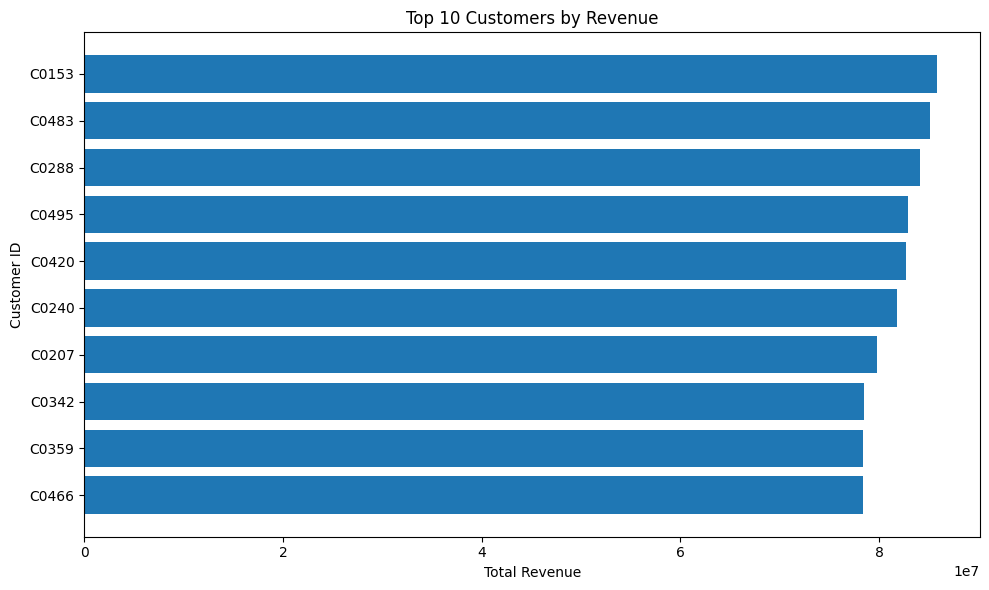

In [33]:
top_customers = (
    customer_performance
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers["customer_id"].astype(str),
    top_customers["total_revenue"]
)

plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")
plt.title("Top 10 Customers by Revenue")

plt.tight_layout()
plt.show()

### **Top Customers by Order Volume**

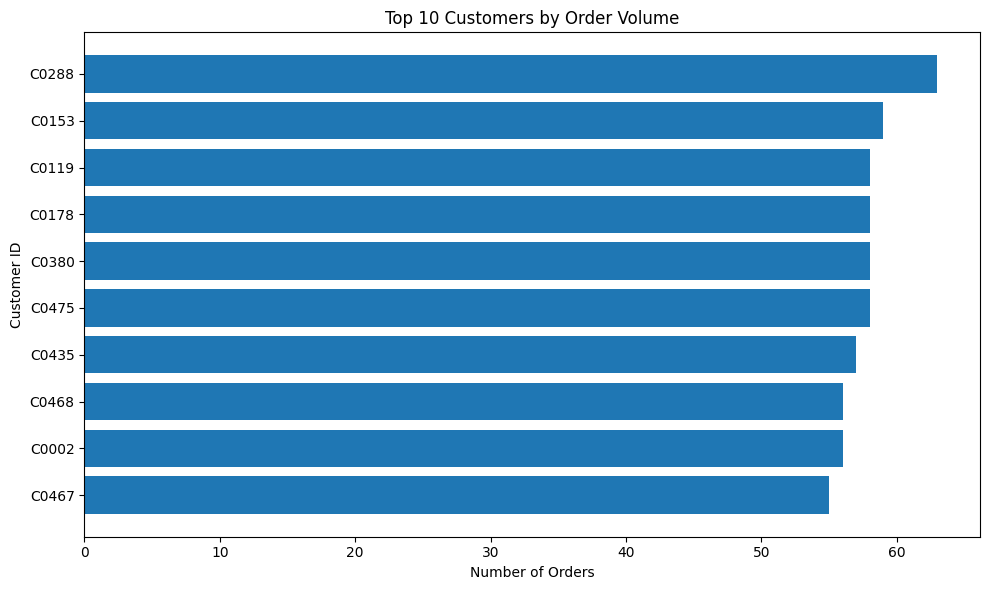

In [34]:
top_order_customers = (
    customer_performance
    .nlargest(10, "total_orders")
    .sort_values("total_orders")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_order_customers["customer_id"].astype(str),
    top_order_customers["total_orders"]
)

plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")
plt.title("Top 10 Customers by Order Volume")

plt.tight_layout()
plt.show()

### **Repeat vs One-Time Customers**

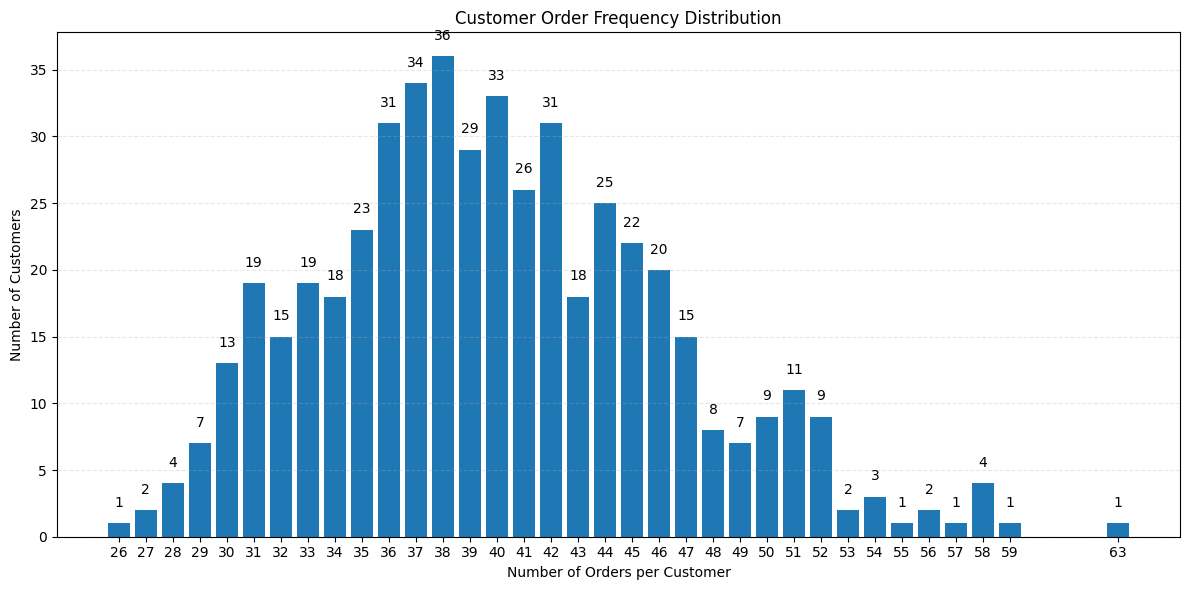

In [36]:
# Count customers by number of orders
order_frequency = (
    customer_performance
    .groupby("total_orders")
    .size()
    .reset_index(name="customer_count")
)

# Sort by number of orders
order_frequency = order_frequency.sort_values("total_orders")

# Plot
plt.figure(figsize=(12, 6))

plt.bar(
    order_frequency["total_orders"],
    order_frequency["customer_count"]
)

plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")
plt.title("Customer Order Frequency Distribution")

# Add values above bars
for x, y in zip(
    order_frequency["total_orders"],
    order_frequency["customer_count"]
):
    plt.text(
        x,
        y + 1,
        str(y),
        ha="center",
        va="bottom"
    )

plt.xticks(
    order_frequency["total_orders"]
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### **Customer Value Segments**

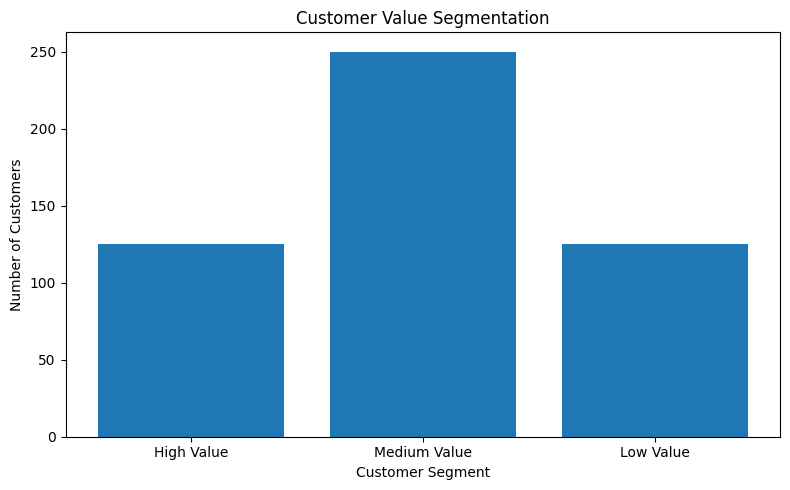

In [37]:
value_counts = (
    customer_performance[
        "customer_value_segment"
    ]
    .value_counts()
    .reindex(
        ["High Value", "Medium Value", "Low Value"]
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    value_counts.index,
    value_counts.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Value Segmentation")

plt.tight_layout()
plt.show()

### **Revenue by Customer Type**

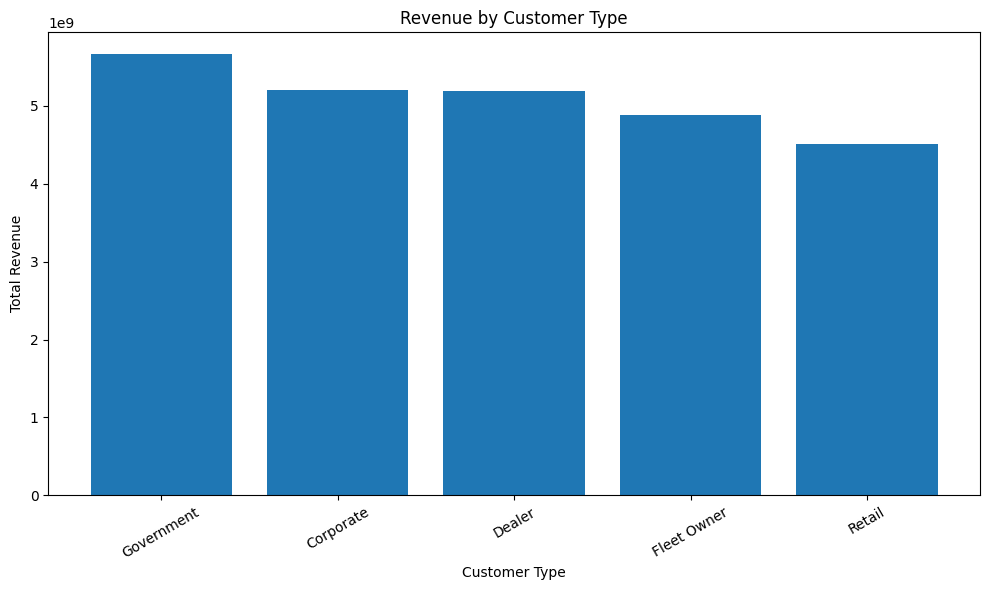

In [38]:
plt.figure(figsize=(10, 6))

plt.bar(
    customer_type_analysis["customer_type"].astype(str),
    customer_type_analysis["total_revenue"]
)

plt.xlabel("Customer Type")
plt.ylabel("Total Revenue")
plt.title("Revenue by Customer Type")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### **Revenue by Industry Segment**

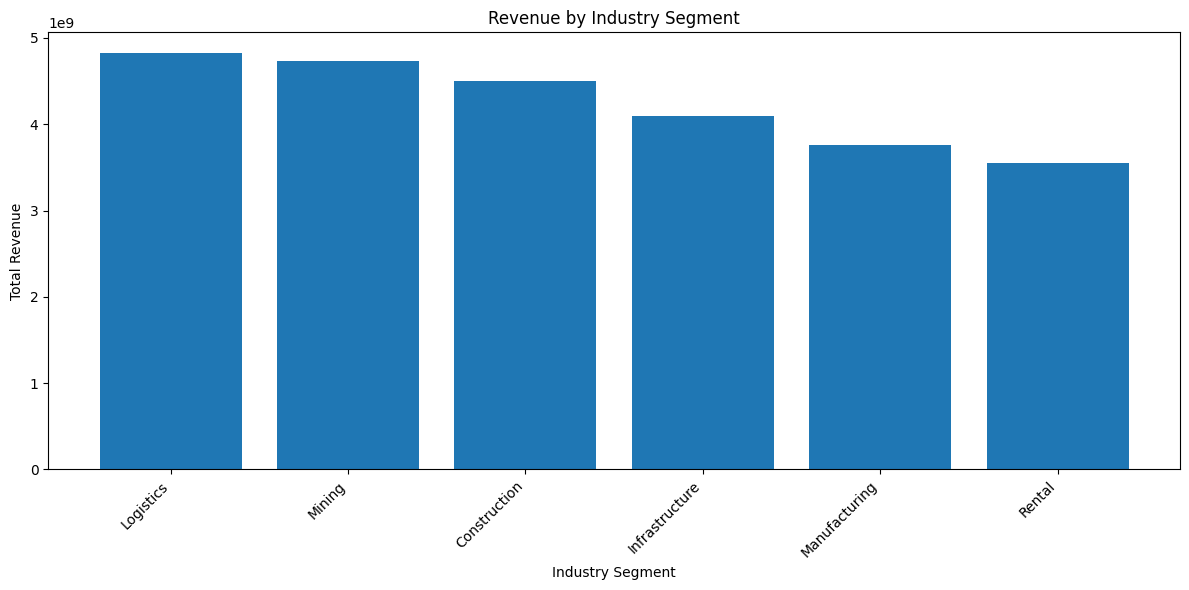

In [39]:
plt.figure(figsize=(12, 6))

plt.bar(
    industry_analysis["industry_segment"].astype(str),
    industry_analysis["total_revenue"]
)

plt.xlabel("Industry Segment")
plt.ylabel("Total Revenue")
plt.title("Revenue by Industry Segment")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### **Revenue by Region**

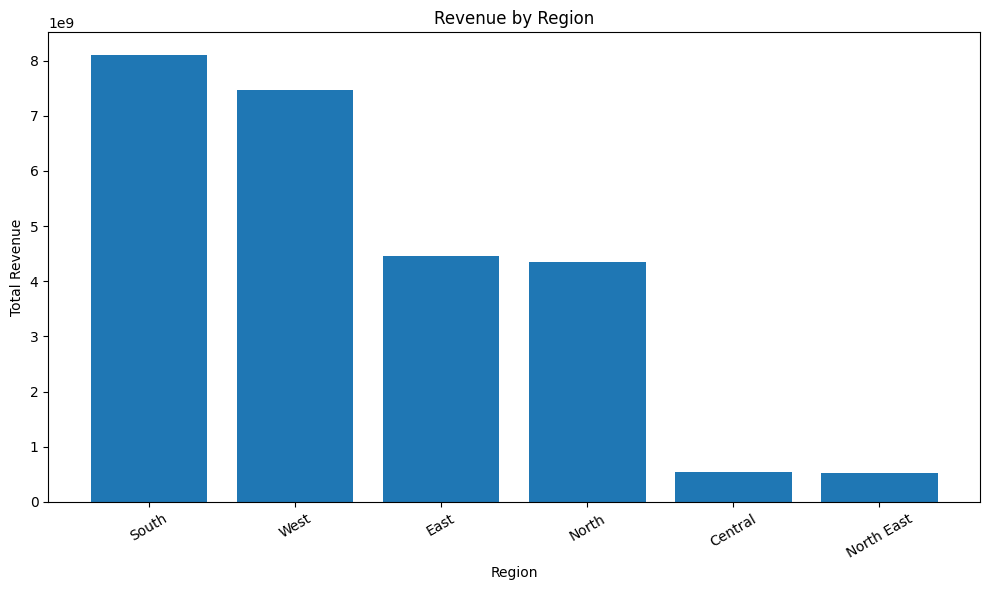

In [40]:
plt.figure(figsize=(10, 6))

plt.bar(
    regional_analysis["region"].astype(str),
    regional_analysis["total_revenue"]
)

plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.title("Revenue by Region")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### **Revenue by Sales Channel**

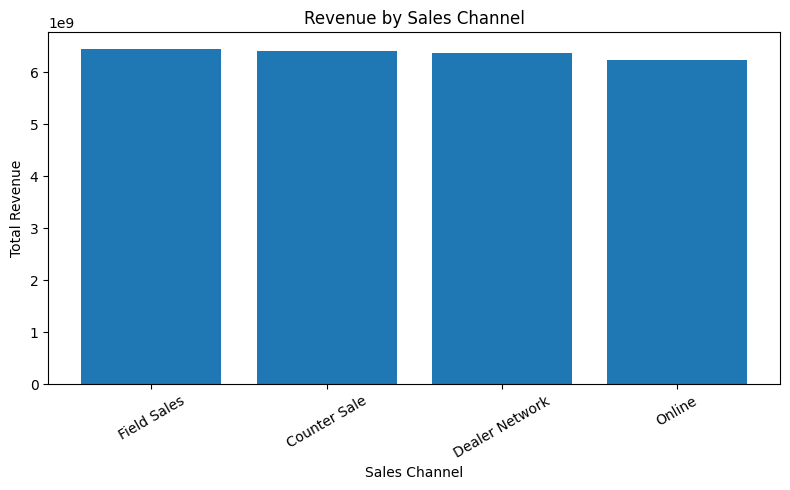

In [41]:
plt.figure(figsize=(8, 5))

plt.bar(
    sales_channel_analysis["sales_channel"].astype(str),
    sales_channel_analysis["total_revenue"]
)

plt.xlabel("Sales Channel")
plt.ylabel("Total Revenue")
plt.title("Revenue by Sales Channel")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### **Monthly Active Customers**

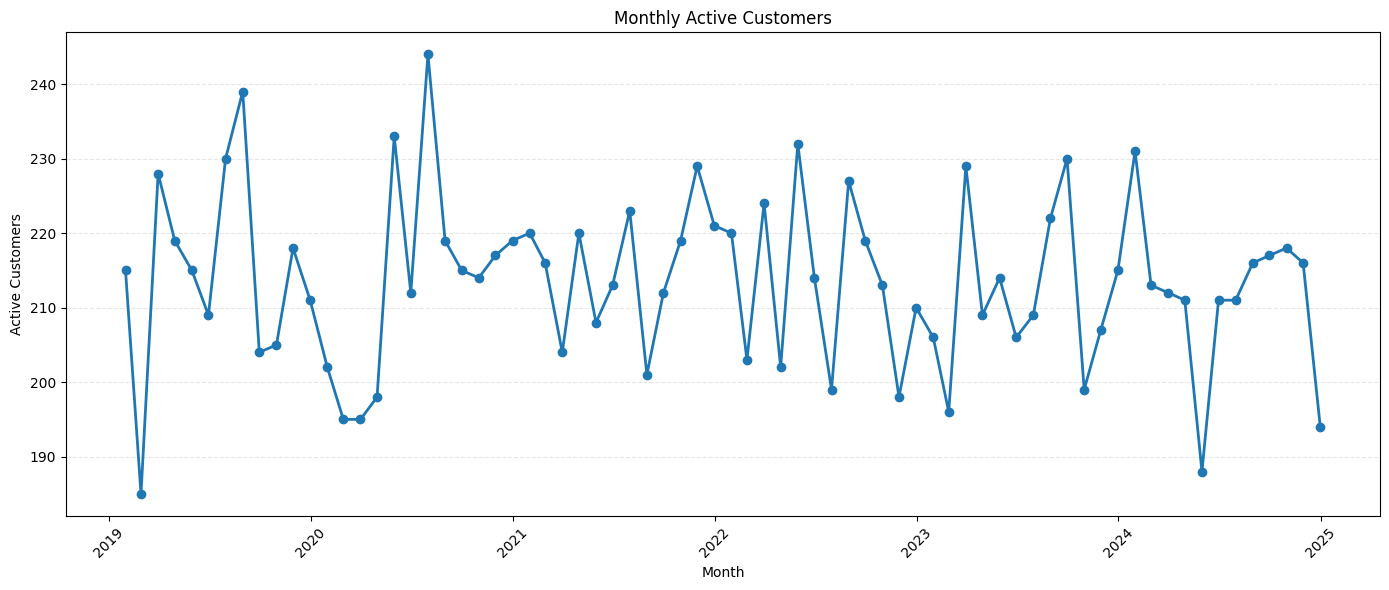

In [42]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_customer_activity["order_date"],
    monthly_customer_activity["active_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Month")
plt.ylabel("Active Customers")
plt.title("Monthly Active Customers")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### **Monthly Repeat Customer Rate**

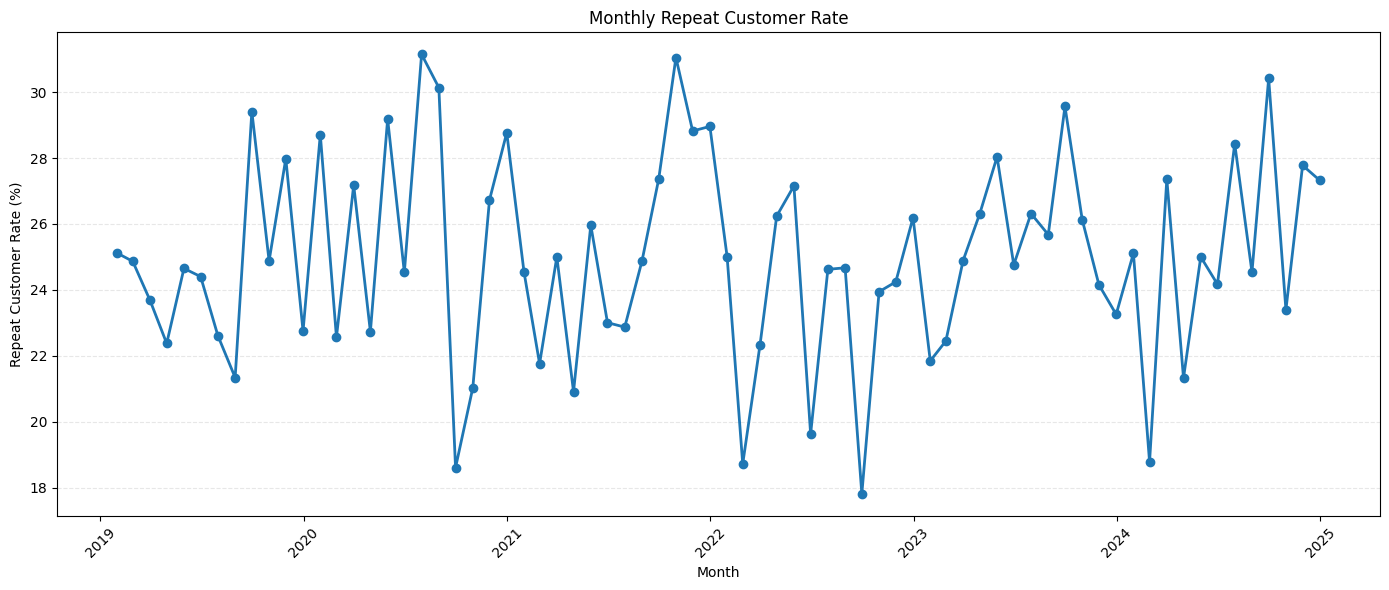

In [43]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_repeat_customers["order_date"],
    monthly_repeat_customers["repeat_customer_rate"],
    marker="o",
    linewidth=2
)

plt.xlabel("Month")
plt.ylabel("Repeat Customer Rate (%)")
plt.title("Monthly Repeat Customer Rate")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### **Customer Revenue Concentration**

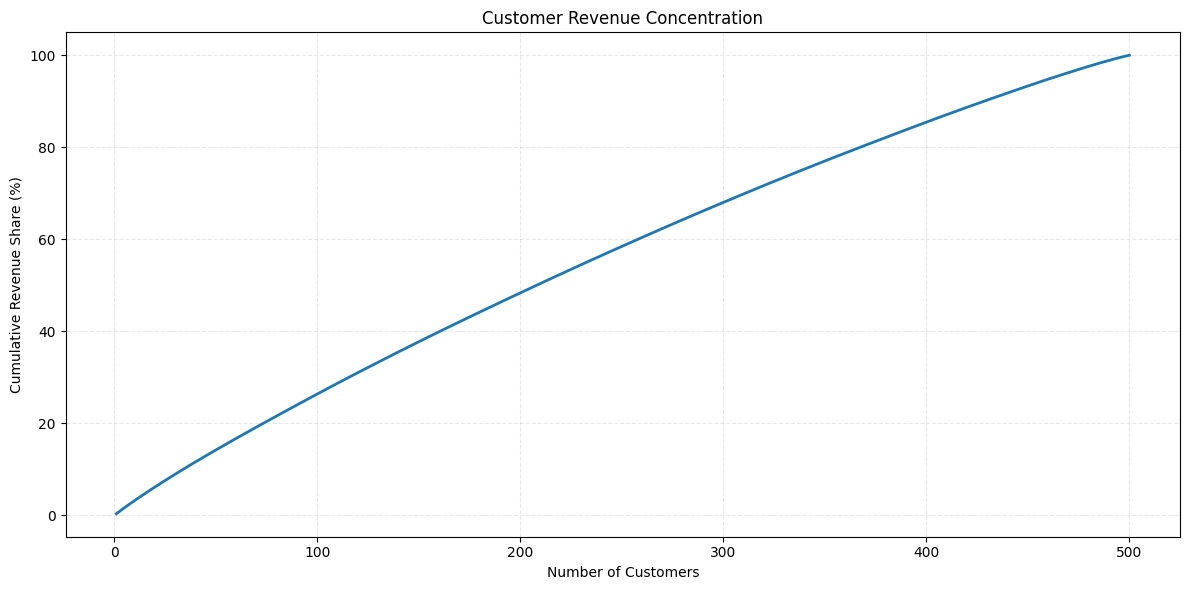

In [44]:
plt.figure(figsize=(12, 6))

plt.plot(
    range(1, len(customer_concentration) + 1),
    customer_concentration[
        "cumulative_revenue_share"
    ],
    linewidth=2
)

plt.xlabel("Number of Customers")
plt.ylabel("Cumulative Revenue Share (%)")
plt.title("Customer Revenue Concentration")

plt.grid(
    axis="both",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### **Product Revenue Among High-Value Customers**

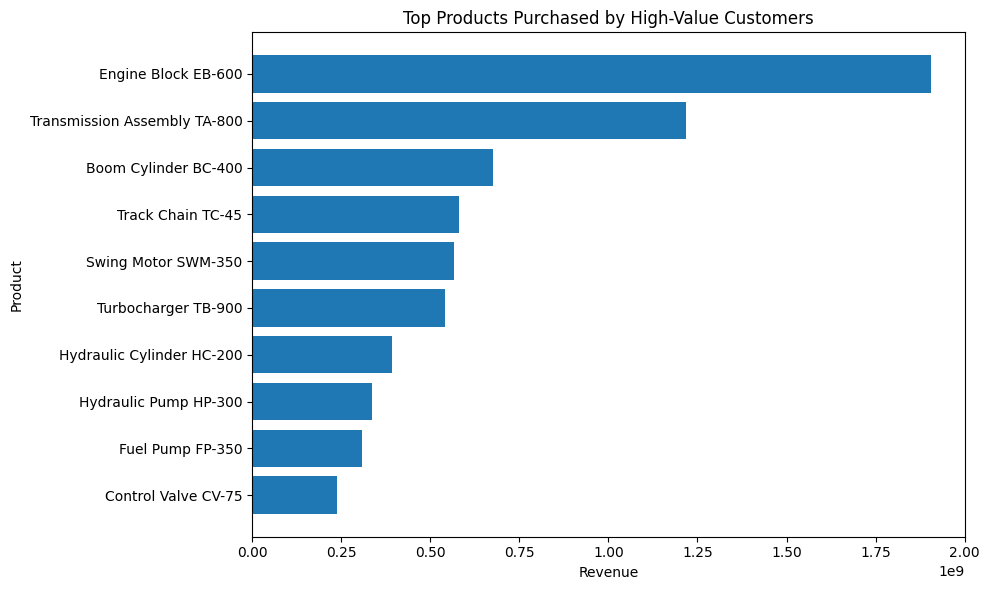

In [45]:
top_high_value_products = (
    high_value_product_analysis
    .head(10)
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_high_value_products["product_name"].astype(str),
    top_high_value_products["total_revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title(
    "Top Products Purchased by High-Value Customers"
)

plt.tight_layout()
plt.show()

## **KPI Summary**

### **Calculate Week 10 KPIs**

In [46]:
week10_kpis = {
    "Total Customers": customer_performance["customer_id"].nunique(),

    "Active Customers": week10_data["customer_id"].nunique(),

    "Total Orders": week10_data["so_id"].nunique(),

    "Total Revenue": week10_data["line_total"].sum(),

    "Total Units Sold": week10_data["quantity"].sum(),

    "Average Customer Revenue": (
        customer_performance["total_revenue"].mean()
    ),

    "Average Orders per Customer": (
        customer_performance["total_orders"].mean()
    ),

    "Repeat Customer Rate (%)": repeat_customer_rate,

    "High-Value Customers": (
        customer_performance[
            "customer_value_segment"
        ]
        .eq("High Value")
        .sum()
    ),

    "One-Time Customers": (
        customer_performance[
            "customer_purchase_status"
        ]
        .eq("One-Time Customer")
        .sum()
    ),

    "Repeat Customers": (
        customer_performance[
            "customer_purchase_status"
        ]
        .eq("Repeat Customer")
        .sum()
    ),

    "Top 10 Customer Revenue Share (%)": (
        top_10_customer_share
    )
}

week10_kpis

{'Total Customers': 500,
 'Active Customers': 500,
 'Total Orders': 20000,
 'Total Revenue': np.int64(25447392560),
 'Total Units Sold': np.int64(1368534),
 'Average Customer Revenue': np.float64(50894785.12),
 'Average Orders per Customer': np.float64(40.0),
 'Repeat Customer Rate (%)': np.float64(100.0),
 'High-Value Customers': np.int64(125),
 'One-Time Customers': np.int64(0),
 'Repeat Customers': np.int64(500),
 'Top 10 Customer Revenue Share (%)': np.float64(3.2127726566575983)}

### **KPI DataFrame**

In [47]:
week10_kpi_table = pd.DataFrame(
    list(week10_kpis.items()),
    columns=["KPI", "Value"]
)

week10_kpi_table

,KPI,Value
0,Total Customers,5.000000e+02
1,Active Customers,5.000000e+02
2,Total Orders,2.000000e+04
3,Total Revenue,2.544739e+10
4,Total Units Sold,1.368534e+06
5,Average Customer Revenue,5.089479e+07
6,Average Orders per Customer,4.000000e+01
7,Repeat Customer Rate (%),1.000000e+02
8,High-Value Customers,1.250000e+02
9,One-Time Customers,0.000000e+00


## **Top Customers Table**

### **Top 10 Customers**

In [48]:
top_10_customers = (
    customer_performance
    .nlargest(10, "total_revenue")
    [
        [
            "customer_id",
            "total_revenue",
            "total_orders",
            "total_units",
            "products_purchased",
            "customer_value_segment",
            "performance_category"
        ]
    ]
)

top_10_customers

,customer_id,total_revenue,total_orders,total_units,products_purchased,customer_value_segment,performance_category
152,C0153,85877020,59,4256,30,High Value,High Performance
482,C0483,85183900,53,3846,30,High Value,High Performance
287,C0288,84094790,63,4626,30,High Value,High Performance
494,C0495,82914040,52,3819,30,High Value,High Performance
419,C0420,82700390,54,4133,30,High Value,High Performance
239,C0240,81776260,50,3799,30,High Value,High Performance
206,C0207,79795630,51,3583,30,High Value,High Performance
341,C0342,78469470,44,3725,30,High Value,High Performance
358,C0359,78412380,52,3851,30,High Value,High Performance
465,C0466,78342990,52,3880,30,High Value,High Performance


### **Top Products for High-Value Customers**

In [49]:
high_value_product_analysis.head(10)

,product_id,product_name,total_units,total_revenue,total_orders,customers
14,P015,Engine Block EB-600,16008,1904952000,1260,125
13,P014,Transmission Assembly TA-800,14591,1218348500,1206,125
20,P021,Boom Cylinder BC-400,14625,675675000,1208,125
3,P004,Track Chain TC-45,14569,579846200,1184,125
18,P019,Swing Motor SWM-350,14215,565757000,1194,125
9,P010,Turbocharger TB-900,15522,541717800,1287,125
10,P011,Hydraulic Cylinder HC-200,14203,392002800,1208,125
0,P001,Hydraulic Pump HP-300,13770,337365000,1146,125
29,P030,Fuel Pump FP-350,14038,307432200,1165,125
21,P022,Control Valve CV-75,14045,237360500,1180,125


## **Business Investigation**

### **Identify High-Value Customers with Low Order Frequency**

In [50]:
high_value_low_frequency = customer_performance[
    (
        customer_performance["customer_value_segment"]
        == "High Value"
    )
    &
    (
        customer_performance["order_frequency_segment"]
        == "Low Frequency"
    )
].sort_values(
    "total_revenue",
    ascending=False
)

high_value_low_frequency.head(20)

,customer_id,total_revenue,total_units,total_orders,products_purchased,branches_used,first_order_date,last_order_date,average_order_value,purchase_frequency,customer_purchase_status,customer_value_segment,order_frequency_segment,revenue_score,order_score,unit_score,customer_performance_score,performance_category
481,C0482,64020490,2843,36,30,1,2019-12-15,2024-12-03,1.778347e+06,0.012663,Repeat Customer,High Value,Low Frequency,74.549035,57.142857,61.456982,66.708771,Medium Performance
233,C0234,63256170,2845,33,30,1,2019-01-09,2024-12-26,1.916854e+06,0.011599,Repeat Customer,High Value,Low Frequency,73.659018,52.380952,61.500216,64.843838,Medium Performance
490,C0491,61370730,2861,32,30,1,2019-03-27,2024-07-04,1.917835e+06,0.011185,Repeat Customer,High Value,Low Frequency,71.463507,50.793651,61.846087,63.339066,Medium Performance
336,C0337,58199500,2775,35,30,1,2019-04-15,2024-08-25,1.662843e+06,0.012613,Repeat Customer,High Value,Low Frequency,67.770749,55.555556,59.987030,62.549447,Medium Performance
165,C0166,58111030,2812,34,30,1,2019-01-18,2024-12-08,1.709148e+06,0.012091,Repeat Customer,High Value,Low Frequency,67.667730,53.968254,60.786857,62.181713,Medium Performance


These customers can be investigated because they generate relatively high revenue but have comparatively low order frequency.

**Identify High-Frequency Customers with Lower Revenue**

In [51]:
high_frequency_low_value = customer_performance[
    (
        customer_performance["order_frequency_segment"]
        == "High Frequency"
    )
    &
    (
        customer_performance["customer_value_segment"]
        == "Low Value"
    )
].sort_values(
    "total_orders",
    ascending=False
)

high_frequency_low_value.head(20)

,customer_id,total_revenue,total_units,total_orders,products_purchased,branches_used,first_order_date,last_order_date,average_order_value,purchase_frequency,customer_purchase_status,customer_value_segment,order_frequency_segment,revenue_score,order_score,unit_score,customer_performance_score,performance_category
469,C0470,42659850,2622,44,30,1,2019-01-25,2024-09-27,969542.045455,0.016781,Repeat Customer,Low Value,High Frequency,49.675513,69.84127,56.679637,57.126065,Medium Performance


### **Save Outputs**

In [55]:
analysis_path = Path("../analysis")

analysis_path.mkdir(
    parents=True,
    exist_ok=True
)

customer_performance.to_csv(
    analysis_path / "customer_performance.csv",
    index=False
)

customer_type_analysis.to_csv(
    analysis_path / "customer_type_analysis.csv",
    index=False
)

industry_analysis.to_csv(
    analysis_path / "industry_segment_analysis.csv",
    index=False
)

regional_analysis.to_csv(
    analysis_path / "regional_customer_analysis.csv",
    index=False
)

sales_channel_analysis.to_csv(
    analysis_path / "sales_channel_analysis.csv",
    index=False
)

customer_concentration.to_csv(
    analysis_path / "customer_revenue_concentration.csv",
    index=False
)

customer_product_analysis.to_csv(
    analysis_path / "customer_product_analysis.csv",
    index=False
)

high_value_product_analysis.to_csv(
    analysis_path / "high_value_customer_products.csv",
    index=False
)

retention_summary.to_csv(
    analysis_path / "customer_retention_summary.csv",
    index=False
)

monthly_customer_activity.to_csv(
    analysis_path / "monthly_customer_activity.csv",
    index=False
)

monthly_repeat_customers.to_csv(
    analysis_path / "monthly_repeat_customer_analysis.csv",
    index=False
)

week10_kpi_table.to_csv(
    analysis_path / "week10_customer_sales_kpis.csv",
    index=False
)